In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer
import os
from tqdm import tqdm
import re
import warnings
from sktime.transformations.series.impute import Imputer
from ABCD import processing_genomics
from ABCD.features import *
warnings.filterwarnings('default')

# Processing Genomics Data

In [2]:
genomics = processing_genomics()

# Subsetting days

In [3]:
from ABCD.subsetting_days import *

In [6]:
adhd_label = '2022_03_18_label_adhd_group_versus_nonclinical_controls.csv'
anxiety_label = '2022_03_18_label_anxiety_group_versus_nonclinical_controls.csv'
bipolar_label = '2022_03_18_label_bipolar_group_versus_nonclinical_controls.csv'
panic_label = '2022_03_18_label_panic_group_versus_nonclinical_controls.csv'
ocd_label = '2022_03_21_label_ocd_group_versus_nonclinical_controls.csv'
names_dict = {'adhd': adhd_label, 'anxiety': anxiety_label, 'bipolar': bipolar_label, 'panic': panic_label, 'ocd': ocd_label}

group = 'adhd'
df_labels = pd.read_csv(f'/home/yl2428/ABCD/labels/{names_dict[group]}')
path_of_data, labels = parse_labels(df_labels, '/home/yl2428/ABCD/aurora01_combined')
# path_of_data, labels = class_balance(np.array(path_of_data), np.array(labels))
path_of_data = list(path_of_data)
labels = list(labels)
list_of_x = []
list_of_y = []
fileNames = []
subjectList = []
print('Begin Preprocessing the Files')
cov_path = '/home/yl2428/ABCD/covariates_processed.csv'
cov = pd.read_csv(cov_path)
fitted = False
add_genomics = True
filter_threshold = 9000
 # set logger to tqdm handler

counter = 0
for index, file in tqdm(enumerate(path_of_data), total = len(path_of_data), desc = "Processing"):
    
    subjectId = parse_file_name(file)
    if add_genomics:
        if len(genomics.loc[genomics['subjectkey_intersection'] == subjectId]) == 0:
            print('No Genomics Info Found')
            continue
    try:
        output = SubsettingDay(file, day = [1, 2], filter_threshold = filter_threshold)
    except AssertionError:
        print('Subsetting failure, value error')
        continue
    
    if output is None:
        continue
    
    output = add_cov(cov, output, subjectId, cov = names_)
    
    if add_genomics:
        output = add_cov(genomics, output, subjectId, 
                         cov = ['PRS_x', 'PRS_y'], cov_key = 'subjectkey_intersection')
    try:
        output = postprocessing(output, False)
    except:
        continue
    # except TypeError:
    #     print('TypeError in Postprocessing')
    #     continue
    if fitted == False:
        fitted = True
    if not checkNa(output):
        print('Error! Final output still containes NaNs')
        continue 
    print('Success')
    list_of_x.append(output)
    list_of_y.append(labels[index])
    fileNames.append(file)
    subjectList.append(subjectId)

X = np.stack(list_of_x, axis = 0)
Y = np.array(list_of_y)
subjectList = np.array(subjectList)
X = X.transpose([0, 2, 1])

X_ts = X[:, 0:7, :]
mean = np.mean(X_ts, axis = (0, 2), keepdims =True)
var = np.var(X_ts, axis = (0, 2), keepdims = True)
X_ts = (X_ts - mean) / np.sqrt(var)

X_ = X[:, 7:, :]
if add_genomics:
    X_33 = X_[:,[32, 34, 35, 36, 37],:]
else:
    X_33 = X_[:,[32, 34, 35],:]
mean_33 = np.mean(X_33, axis = 0, keepdims =True)
var_33 = np.var(X_33, axis = 0, keepdims = True)
X_33 = (X_33 - mean_33) / np.sqrt(var_33)

if add_genomics:
    X_[:,[32, 34, 35, 36, 37],:] = X_33
else:
    X_[:,[32, 34, 35],:] = X_33
# Reverse some unwanted normalization
X_out = np.concatenate([X_ts, X_], axis = 1)
if add_genomics:
    np.save(f'./processed_data/new_genomic_all_{filter_threshold}_{group}_non_clinical_2_3_X.npy', X_out)
    np.save(f'./processed_data/new_genomic_all_{filter_threshold}_{group}_non_clinical_2_3_subject.npy', subjectList)
    np.save(f'./processed_data/new_genomic_all_{filter_threshold}_{group}_non_clinical_2_3_Y.npy', Y)
else:
    np.save(f'./processed_data/all_{filter_threshold}_{group}_non_clinical_2_3_X.npy', X_out)
    np.save(f'./processed_data/all_{filter_threshold}_{group}_non_clinical_2_3_subject.npy', subjectList)
    np.save(f'./processed_data/all_{filter_threshold}_{group}_non_clinical_2_3_Y.npy', Y)

Begin Preprocessing the Files


Processing:   0%|          | 0/3558 [00:00<?, ?it/s]

No Genomics Info Found
                Wear_Time  Intensity  Level  Steps  Calories  HeartRateValue  \
41760 2019-12-03 00:00:00        0.0   deep    0.0    0.8838            92.0   
41761 2019-12-03 00:01:00        0.0   deep    0.0    0.8838            94.0   
41762 2019-12-03 00:02:00        0.0   deep    0.0    0.8838            94.0   
41763 2019-12-03 00:03:00        0.0   deep    0.0    0.8838            94.0   
41764 2019-12-03 00:04:00        0.0   deep    0.0    0.8838            94.0   
...                   ...        ...    ...    ...       ...             ...   
44635 2019-12-04 23:55:00        0.0  light    0.0    0.8838            82.0   
44636 2019-12-04 23:56:00        0.0  light    0.0    0.8838            79.0   
44637 2019-12-04 23:57:00        0.0  light    0.0    0.8838            80.0   
44638 2019-12-04 23:58:00        0.0  light    0.0    0.8838            81.0   
44639 2019-12-04 23:59:00        0.0  light    0.0    0.8838            80.0   

       Intensity

/gpfs/ysm/project/gerstein/yl2428/conda_envs/sktime_lyy/lib/python3.7/site-packages/sktime/transformations/series/impute.py:181: DeprecationWarning: Imputer methods "drift", "mean", "median", "random" have been
                moved to the fit() method, so usage via transform() is
                deprecated. To still fit on the transform data only, please use the
                new FitInTransform transformer.
                
  DeprecationWarning,
/gpfs/ysm/project/gerstein/yl2428/conda_envs/sktime_lyy/lib/python3.7/site-packages/sktime/transformations/series/impute.py:307: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col][na_index] = self._forecaster.predict(fh=fh, X=y)
/gpfs/ysm/project/gerstein/yl2428/conda_envs/sktime_lyy/lib/python3.7/site-packages/sktime/transformations/series/impute.py:307: 

Success
No Genomics Info Found
Subsetting Failure. No satisfiable day frames founded. The failed filename is NDAR_INV55285WTD_combined.csv
No Genomics Info Found


...

Subsetting Failure. No satisfiable day frames founded. The failed filename is NDAR_INVW4JM1V5R_combined.csv
                Wear_Time  Intensity  Level  Steps  Calories  HeartRateValue  \
44640 2019-09-10 00:00:00        0.0  light    0.0   0.94070            80.0   
44641 2019-09-10 00:01:00        0.0  light    0.0   0.94070            78.0   
44642 2019-09-10 00:02:00        0.0  light    0.0   0.94070            76.0   
44643 2019-09-10 00:03:00        0.0  light    0.0   0.94070            75.0   
44644 2019-09-10 00:04:00        0.0  light    0.0   0.94070            75.0   
...                   ...        ...    ...    ...       ...             ...   
47515 2019-09-11 23:55:00        0.0   deep    0.0   0.94070            73.0   
47516 2019-09-11 23:56:00        0.0   deep    0.0   0.94070            77.0   
47517 2019-09-11 23:57:00        0.0   wake    0.0   1.22291            97.0   
47518 2019-09-11 23:58:00        0.0   wake    0.0   1.03477            87.0   
47519 2019-0

/gpfs/ysm/project/gerstein/yl2428/conda_envs/sktime_lyy/lib/python3.7/site-packages/sktime/transformations/series/impute.py:181: DeprecationWarning: Imputer methods "drift", "mean", "median", "random" have been
                moved to the fit() method, so usage via transform() is
                deprecated. To still fit on the transform data only, please use the
                new FitInTransform transformer.
                
  DeprecationWarning,
/gpfs/ysm/project/gerstein/yl2428/conda_envs/sktime_lyy/lib/python3.7/site-packages/sktime/transformations/series/impute.py:307: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col][na_index] = self._forecaster.predict(fh=fh, X=y)
/gpfs/ysm/project/gerstein/yl2428/conda_envs/sktime_lyy/lib/python3.7/site-packages/sktime/transformations/series/impute.py:307: 

Success
No Genomics Info Found
No Genomics Info Found
                Wear_Time  Intensity  Level  Steps  Calories  HeartRateValue  \
33120 2019-12-31 00:00:00        0.0  light    0.0    0.6547            73.0   
33121 2019-12-31 00:01:00        0.0  light    0.0    0.6547            74.0   
33122 2019-12-31 00:02:00        0.0  light    0.0    0.6547            75.0   
33123 2019-12-31 00:03:00        0.0  light    0.0    0.6547            74.0   
33124 2019-12-31 00:04:00        0.0  light    0.0    0.6547            73.0   
...                   ...        ...    ...    ...       ...             ...   
35995 2020-01-01 23:55:00        NaN    NaN    NaN       NaN             NaN   
35996 2020-01-01 23:56:00        NaN    NaN    NaN       NaN             NaN   
35997 2020-01-01 23:57:00        NaN    NaN    NaN       NaN             NaN   
35998 2020-01-01 23:58:00        NaN    NaN    NaN       NaN             NaN   
35999 2020-01-01 23:59:00        NaN    NaN    NaN       NaN      

/gpfs/ysm/project/gerstein/yl2428/conda_envs/sktime_lyy/lib/python3.7/site-packages/sktime/transformations/series/impute.py:181: DeprecationWarning: Imputer methods "drift", "mean", "median", "random" have been
                moved to the fit() method, so usage via transform() is
                deprecated. To still fit on the transform data only, please use the
                new FitInTransform transformer.
                
  DeprecationWarning,
/gpfs/ysm/project/gerstein/yl2428/conda_envs/sktime_lyy/lib/python3.7/site-packages/sktime/transformations/series/impute.py:307: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col][na_index] = self._forecaster.predict(fh=fh, X=y)
/gpfs/ysm/project/gerstein/yl2428/conda_envs/sktime_lyy/lib/python3.7/site-packages/sktime/transformations/series/impute.py:307: 

Success
No Genomics Info Found
Subsetting Failure. No satisfiable day frames founded. The failed filename is NDAR_INV0ULZKXXG_combined.csv
No Genomics Info Found
No Genomics Info Found
No Genomics Info Found
No Genomics Info Found
No Genomics Info Found
No Genomics Info Found
No Genomics Info Found


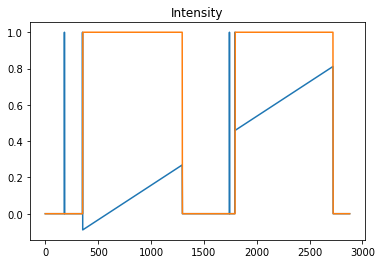

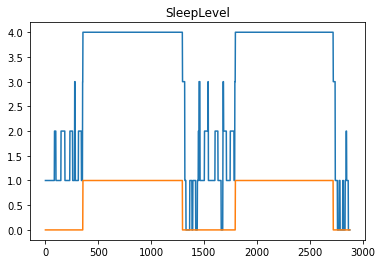

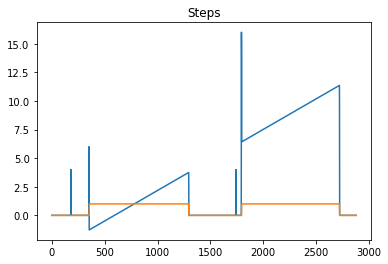

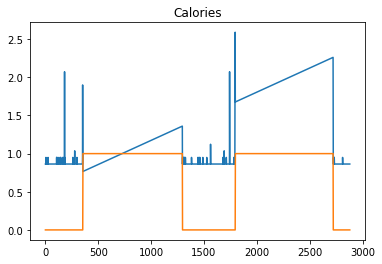

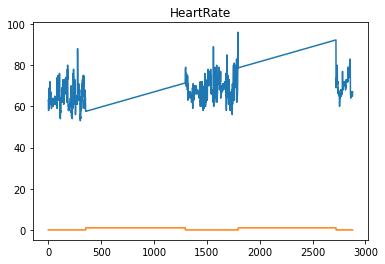

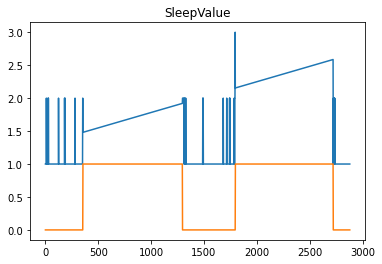

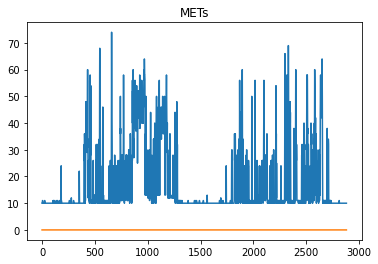

In [70]:
for i in range(7):
    plt.plot(output[:, i])
    plt.plot(output[:,-7 + i])
    plt.title(ts[i])
    plt.show()